In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

## Neural Network

In [2]:
class RelativisticPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

## Physics Loss with Dynamic Spatial Weighting

In [3]:
def compute_loss(model, x_pde, t_pde, x_ic, u_ic, x_l, x_r, t_bc, nu=0.0):
    # --- PDE Loss ---
    x_pde.requires_grad_(True)
    t_pde.requires_grad_(True)
    u = model(x_pde, t_pde)
    
    u_t = torch.autograd.grad(u, t_pde, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x_pde, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_pde, torch.ones_like(u_x), create_graph=True)[0]
    
    # Relativistic velocity constraint
    v = u / torch.sqrt(1 + u**2)
    residual = u_t + v * u_x - nu * u_xx
    
    # Dynamic Weighting: Focus the optimizer on steep gradients (the shock)
    with torch.no_grad():
        weights = 1.0 + 10.0 * torch.abs(u_x) / (torch.max(torch.abs(u_x)) + 1e-8)
    
    loss_pde = torch.mean(weights * residual**2)
    
    # --- Initial Condition Loss ---
    loss_ic = torch.mean((model(x_ic, torch.zeros_like(x_ic)) - u_ic)**2)
    
    # --- Boundary Condition Loss ---
    # The Gaussian is essentially zero at x = -1 and x = 1, so we enforce u=0
    loss_bc = torch.mean(model(x_l, t_bc)**2 + model(x_r, t_bc)**2)
    
    # Heavily weight the IC so the network doesn't collapse to the trivial u=0 solution
    return loss_pde + 20.0 * loss_ic + loss_bc

## Analytical Solution (Method of Characteristics)

In [4]:
def analytical_u_gaussian(x_array, t_val):
    """
    Solves u = exp(-20 * (x - v(u)*t)^2) implicitly.
    """
    def implicit_func(u_guess, x_individual):
        v = u_guess / np.sqrt(1 + u_guess**2)
        return u_guess - np.exp(-20.0 * (x_individual - v * t_val)**2)

    u_analytical = []
    for x_val in x_array:
        # Initial guess based on the t=0 profile
        initial_guess = np.exp(-20.0 * x_val**2)
        sol = fsolve(implicit_func, initial_guess, args=(x_val,))
        u_analytical.append(sol[0])
        
    return np.array(u_analytical)

##  Data Setup

In [5]:
n_pde = 4000
n_ic = 500

# Randomly sample PDE points inside the domain
x_pde = (torch.rand(n_pde, 1) * 2 - 1)  # [-1, 1]
t_pde = torch.rand(n_pde, 1) * 0.4      # [0, 0.4]

# Initial Condition: Gaussian Pulse
x_ic = (torch.rand(n_ic, 1) * 2 - 1)
u_ic = torch.exp(-20.0 * x_ic**2)

# Boundary Conditions
t_bc = torch.rand(n_ic, 1) * 0.4
x_l = torch.ones(n_ic, 1) * -1.0
x_r = torch.ones(n_ic, 1) * 1.0

## Training Phase

In [6]:
model = RelativisticPINN()

print("Phase 1: Training with Adam...")
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(2500):
    optimizer_adam.zero_grad()
    loss = compute_loss(model, x_pde, t_pde, x_ic, u_ic, x_l, x_r, t_bc)
    loss.backward()
    optimizer_adam.step()
    
    if epoch % 500 == 0: 
        print(f"Adam Epoch {epoch:04d} | Total Loss: {loss.item():.6f}")

Phase 1: Training with Adam...
Adam Epoch 0000 | Total Loss: 2.555699
Adam Epoch 0500 | Total Loss: 0.027675
Adam Epoch 1000 | Total Loss: 0.009470
Adam Epoch 1500 | Total Loss: 0.005511
Adam Epoch 2000 | Total Loss: 0.003314


In [7]:
print("\nPhase 2: Refining with L-BFGS (Focusing on the shock front)...")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    max_iter=50, 
    tolerance_grad=1e-7, 
    tolerance_change=1e-9, 
    history_size=50
)


Phase 2: Refining with L-BFGS (Focusing on the shock front)...


In [8]:
def closure():
    optimizer_lbfgs.zero_grad()
    loss = compute_loss(model, x_pde, t_pde, x_ic, u_ic, x_l, x_r, t_bc)
    loss.backward()
    return loss

In [9]:
optimizer_lbfgs.step(closure)
final_loss = closure()
print(f"L-BFGS Complete | Final Loss: {final_loss.item():.6f}")

L-BFGS Complete | Final Loss: 0.001786


In [10]:
# 6. Plotting and Comparison
def plot_results(model, t_to_check=0.15):
    x_vals = np.linspace(-1, 1, 400)
    
    # Calculate Analytical Solution
    u_ana = analytical_u_gaussian(x_vals, t_to_check)
    
    # Get PINN Prediction
    x_torch = torch.tensor(x_vals, dtype=torch.float32).view(-1, 1)
    t_torch = torch.ones_like(x_torch) * t_to_check
    with torch.no_grad():
        u_pinn = model(x_torch, t_torch).numpy().flatten()
    
    plt.figure(figsize=(10, 6))
    
    # Plot Initial Condition
    u_init = np.exp(-20.0 * x_vals**2)
    plt.plot(x_vals, u_init, 'g:', lw=2, alpha=0.6, label="Initial Condition (t=0)")
    
    # Plot Analytical and PINN
    plt.plot(x_vals, u_ana, 'k--', lw=2, label=f"Analytical (t={t_to_check})")
    plt.plot(x_vals, u_pinn, 'r-', lw=2, alpha=0.8, label=f"PINN (t={t_to_check})")
    
    plt.title("Relativistic Simple Wave: Gaussian Pulse Steepening")
    plt.xlabel("Position x")
    plt.ylabel("Relativistic Momentum u")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim([-0.6, 0.8])
    plt.show()

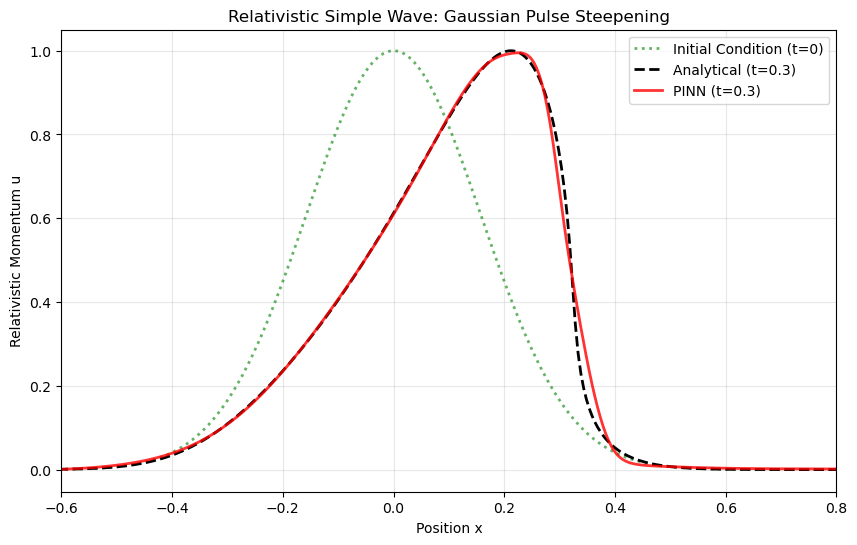

In [13]:
# Visualize the wave steepening just before total shock breakdown
plot_results(model, t_to_check=0.3)